In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from simple_transformer.benchmark import benchmark_forward_latency, benchmark_generate_latency
from simple_transformer.checkpoint import CheckpointConfig, CheckpointManager
from simple_transformer.config import local_training_config, small_model_config
from simple_transformer.metrics import TensorBoardTrainingObserver
from simple_transformer.model import SimpleTransformerLM, count_parameters
from simple_transformer.quantization import make_torchao_int8_dynamic_model
from simple_transformer.data import make_arithmetic_dataset, make_train_val_loaders
from simple_transformer.train import fit


W0718 16:30:20.066000 89871 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
W0718 16:30:20.086000 89871 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


In [2]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps"
print(torch.__version__)
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.12.0
mps


In [3]:
custom_examples = [
    "0+0=",
    "5+7=",
    "45-54=",
    "99-1=",
    "12*3=",
    "9*9=",
    "20/4=",
    "9/2=",
    "123+456=",
    "745-84=",
    "11*11=",
    "100/3=",
    "999+1=",
    "999-100=",
    "99*12=",
    "999/7=",
]

for example in custom_examples:
    print(example)


0+0=
5+7=
45-54=
99-1=
12*3=
9*9=
20/4=
9/2=
123+456=
745-84=
11*11=
100/3=
999+1=
999-100=
99*12=
999/7=


In [4]:
def show_generations(model, tokenizer, examples):
    model.eval()
    prompt_ids = [tokenizer.encode(example) for example in examples]
    generated_ids = model.generate_batch(
        prompt_ids,
        eos_token_id=tokenizer.eos_token_id,
    )

    for prompt, output_ids in zip(examples, generated_ids):
        print(f"{prompt:>8} -> {tokenizer.decode(output_ids)}")

In [5]:
train_config = local_training_config(max_digits=3, device=device)

model_config = small_model_config(
    max_digits=train_config.max_digits,
    device=train_config.device,
)
model = SimpleTransformerLM(model_config)
train_loader, val_loader, tokenizer = make_train_val_loaders(train_config)
run_name = datetime.now().strftime("arithmetic-%Y%m%d-%H%M%S")
run_dir = Path("..") / "runs" / run_name
checkpoint_dir = Path("..") / "checkpoints" / run_name
checkpoint_manager = CheckpointManager(
    CheckpointConfig(checkpoint_dir=checkpoint_dir, keep_last=3)
)
observer = TensorBoardTrainingObserver(run_dir)
observer.log_config(
    training_config=train_config,
    model_config=model_config,
    parameter_count=count_parameters(model),
)

print(f"parameters: {count_parameters(model):,}")
print(f"force flash: {model_config.force_flash}")
print(f"train batches: {len(train_loader)}, validation batches: {len(val_loader)}")
print(f"TensorBoard log dir: {run_dir}")
print(f"Checkpoint dir: {checkpoint_dir}")
print("Terminal: tensorboard --logdir runs")
print("Before training:")
show_generations(model, tokenizer, custom_examples)


parameters: 2,032,896
force flash: False
train batches: 1024, validation batches: 256
TensorBoard log dir: ../runs/arithmetic-20260718-163023
Checkpoint dir: ../checkpoints/arithmetic-20260718-163023
Terminal: tensorboard --logdir runs
Before training:
    0+0= -> 0+0============
    5+7= -> 5+7=====+++++++
  45-54= -> 45-54==========
   99-1= -> 99-1===========
   12*3= -> 12*3=9999999999
    9*9= -> 9*9============
   20/4= -> 20/4===========
    9/2= -> 9/2============
123+456= -> 123+456=0000000
 745-84= -> 745-84=======++
  11*11= -> 11*11=000000000
  100/3= -> 100/3=---------
  999+1= -> 999+1======2222
999-100= -> 999-100=9999999
  99*12= -> 99*12==========
  999/7= -> 999/7=====22222


In [6]:
def print_epoch(epoch, train, validation):
    print(
        f"epoch {epoch:02d} | "
        f"train loss {train.loss:.4f} acc {train.accuracy:.3f} | "
        f"val loss {validation.loss:.4f} acc {validation.accuracy:.3f} | "
        f"lr {train.learning_rate:.2e}"
    )

try:
    history = fit(
        model,
        train_loader,
        val_loader,
        train_config,
        on_epoch=print_epoch,
        observer=observer,
        checkpoint_manager=checkpoint_manager,
    )
finally:
    observer.close()
    checkpoint_manager.close()


epoch 01 | train loss 1.4900 acc 0.448 | val loss 1.2643 acc 0.513 | lr 2.98e-04
epoch 02 | train loss 1.2078 acc 0.531 | val loss 1.1560 acc 0.546 | lr 2.93e-04
epoch 03 | train loss 1.0934 acc 0.570 | val loss 0.9413 acc 0.625 | lr 2.85e-04
epoch 04 | train loss 0.7884 acc 0.687 | val loss 0.6496 acc 0.744 | lr 2.74e-04
epoch 05 | train loss 0.5914 acc 0.765 | val loss 0.5571 acc 0.783 | lr 2.61e-04
epoch 06 | train loss 0.5244 acc 0.795 | val loss 0.5452 acc 0.788 | lr 2.44e-04
epoch 07 | train loss 0.5008 acc 0.803 | val loss 0.5036 acc 0.800 | lr 2.26e-04
epoch 08 | train loss 0.4810 acc 0.810 | val loss 0.4728 acc 0.812 | lr 2.07e-04
epoch 09 | train loss 0.4655 acc 0.816 | val loss 0.4667 acc 0.814 | lr 1.86e-04
epoch 10 | train loss 0.4486 acc 0.824 | val loss 0.4473 acc 0.824 | lr 1.65e-04
epoch 11 | train loss 0.4315 acc 0.831 | val loss 0.4349 acc 0.828 | lr 1.44e-04
epoch 12 | train loss 0.4174 acc 0.836 | val loss 0.4286 acc 0.831 | lr 1.23e-04
epoch 13 | train loss 0.4047

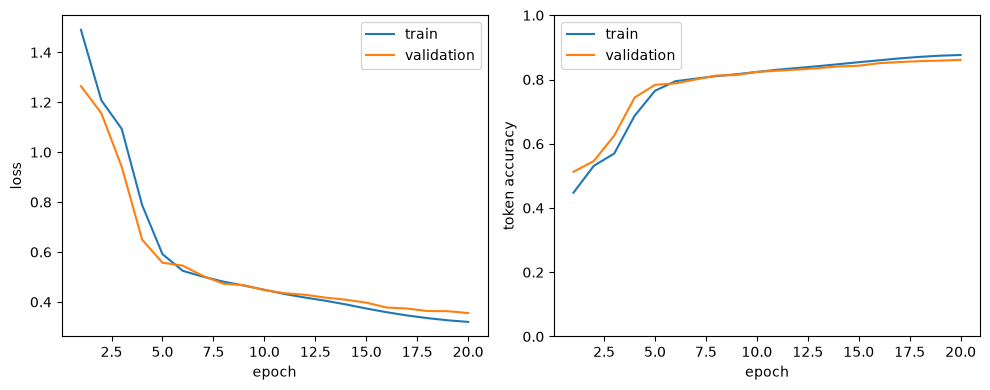

In [12]:
epochs = range(1, len(history.train) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, [metrics.loss for metrics in history.train], label="train")
plt.plot(epochs, [metrics.loss for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, [metrics.accuracy for metrics in history.train], label="train")
plt.plot(epochs, [metrics.accuracy for metrics in history.validation], label="validation")
plt.xlabel("epoch")
plt.ylabel("token accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

In [6]:
print("After training:")
show_generations(model, tokenizer, custom_examples)

final_train = history.train[-1]
final_validation = history.validation[-1]
print(
    f"final train loss={final_train.loss:.4f}, "
    f"train acc={final_train.accuracy:.3f}, "
    f"val loss={final_validation.loss:.4f}, "
    f"val acc={final_validation.accuracy:.3f}"
)

After training:
    0+0= -> 0+0============
    5+7= -> 5+7=====+++++++
  45-54= -> 45-54==========
   99-1= -> 99-1===========
   12*3= -> 12*3=9999999999
    9*9= -> 9*9============
   20/4= -> 20/4===========
    9/2= -> 9/2============
123+456= -> 123+456=0000000
 745-84= -> 745-84=======++
  11*11= -> 11*11=000000000
  100/3= -> 100/3=---------
  999+1= -> 999+1======2222
999-100= -> 999-100=9999999
  99*12= -> 99*12==========
  999/7= -> 999/7=====22222


NameError: name 'history' is not defined

In [7]:
checkpoint_dir = Path("..") / "checkpoints" / "arithmetic-20260717-133400"  # Picking latest checkpoint
checkpoint_manager = CheckpointManager(CheckpointConfig(checkpoint_dir=checkpoint_dir))
latest_checkpoint = checkpoint_manager.latest_checkpoint()
print(f"latest checkpoint: {latest_checkpoint}\n")

inference_model = SimpleTransformerLM(model_config)
checkpoint_manager.load_checkpoint(
    latest_checkpoint,
    model=inference_model,
    map_location=device,
)
inference_model = inference_model.to(device).eval()
# inference_model = torch.compile(inference_model)  # Wasn't particularly useful
# inference_model = make_torchao_int8_dynamic_model(inference_model, compile_model=True).to(device)

show_generations(inference_model, tokenizer, custom_examples)

latest checkpoint: ../checkpoints/arithmetic-20260717-133400/epoch-0020.pt

    0+0= -> 0+0=0
    5+7= -> 5+7=53
  45-54= -> 45-54=-1
   99-1= -> 99-1=98
   12*3= -> 12*3=32
    9*9= -> 9*9=80
   20/4= -> 20/4=0
    9/2= -> 9/2=2
123+456= -> 123+456=579
 745-84= -> 745-84=661
  11*11= -> 11*11=111
  100/3= -> 100/3=4
  999+1= -> 999+1=980
999-100= -> 999-100=899
  99*12= -> 99*12=1168
  999/7= -> 999/7=149


In [8]:
# Evaluate exact-match accuracy on 100 randomly generated examples.

random_examples = make_arithmetic_dataset(
    num_examples=200,
    max_digits=3,
    operations=train_config.operations,
    seed=train_config.seed + 1,
)
prompts = [example.text.split("=")[0] + "=" for example in random_examples]
prompt_ids = [tokenizer.encode(prompt) for prompt in prompts]

# with torch.autocast(device_type=device, dtype=torch.bfloat16):
outputs = inference_model.generate_batch(
    prompt_ids,
    eos_token_id=tokenizer.eos_token_id,
)

predictions = [tokenizer.decode(output.tolist()) for output in outputs]
targets = [example.text for example in random_examples]
wrong_cases = [
    (prompt, target, prediction)
    for prompt, target, prediction in zip(prompts, targets, predictions)
    if prediction != target
]
accuracy = (len(targets) - len(wrong_cases)) / len(targets)

print(f"accuracy: {accuracy:.2%} ({len(targets) - len(wrong_cases)}/{len(targets)})")
print(f"wrong cases: {len(wrong_cases)}")

for prompt, target, prediction in wrong_cases:
    print(f"{prompt:>12} expected {target:<18} got {prediction}")

accuracy: 79.50% (159/200)
wrong cases: 41
    224*133= expected 224*133=29792      got 224*133=29052
    209*332= expected 209*332=69388      got 209*332=67088
    539*652= expected 539*652=351428     got 539*652=344248
    628*741= expected 628*741=465348     got 628*741=462208
    320*267= expected 320*267=85440      got 320*267=84440
    281*910= expected 281*910=255710     got 281*910=254510
     26*364= expected 26*364=9464        got 26*364=9224
    907*133= expected 907*133=120631     got 907*133=118221
    453-447= expected 453-447=6          got 453-447=8
    264*506= expected 264*506=133584     got 264*506=130824
    991*707= expected 991*707=700637     got 991*707=699087
    227*353= expected 227*353=80131      got 227*353=78221
    510*142= expected 510*142=72420      got 510*142=72520
    261*151= expected 261*151=39411      got 261*151=39581
     189*23= expected 189*23=4347        got 189*23=4467
    687*715= expected 687*715=491205     got 687*715=482245
    857*663= e

In [9]:
# Benchmark inference latency for the trained model.
# These metrics are useful as the baseline before trying quantized variants.

# Use one shared batch size for forward and generation so examples/sec is comparable.
# Token/sec still needs mode-specific interpretation: forward consumes input tokens,
# while generation produces new tokens through an autoregressive loop.
forward_batch = next(iter(val_loader))

prompt_buckets = {}
for prompt in prompts:
    ids = tokenizer.encode(prompt)
    prompt_buckets.setdefault(len(ids), []).append(ids)

benchmark_prompt_ids = max(prompt_buckets.values(), key=len)
benchmark_batch_size = min(
    train_config.batch_size,
    forward_batch["input_ids"].size(0),
    len(benchmark_prompt_ids),
)
benchmark_prompt_ids = benchmark_prompt_ids[:benchmark_batch_size]

forward_input_ids = forward_batch["input_ids"][:benchmark_batch_size].to(device)
generation_input_ids = torch.tensor(benchmark_prompt_ids, dtype=torch.long, device=device)
generation_new_tokens = model_config.max_seq_len - generation_input_ids.size(1)

forward_latency = benchmark_forward_latency(
    inference_model,
    forward_input_ids,
    warmup=10,
    repeats=100,
)

generation_latency = benchmark_generate_latency(
    inference_model,
    generation_input_ids,
    max_new_tokens=generation_new_tokens,
    eos_token_id=tokenizer.eos_token_id,
    warmup=5,
    repeats=50,
)

latency_rows = [
    {
        "name": "forward",
        "batch_size": forward_input_ids.size(0),
        "seq_len": forward_input_ids.size(1),
        "new_tokens": None,
        "latency": forward_latency,
        "token_count": forward_input_ids.numel(),
        "token_label": "input_tok/s",
    },
    {
        "name": "generate",
        "batch_size": generation_input_ids.size(0),
        "seq_len": generation_input_ids.size(1),
        "new_tokens": generation_new_tokens,
        "latency": generation_latency,
        "token_count": generation_input_ids.size(0) * generation_new_tokens,
        "token_label": "gen_tok/s",
    },
]

print(f"exact-match accuracy: {accuracy:.2%}")
print("latency benchmark:")
print(
    "name      batch  seq  new  mean_ms  std_ms  median_ms  p95_ms  "
    "calls/s  examples/s  token_rate"
)
for row in latency_rows:
    latency = row["latency"]
    examples_per_second = row["batch_size"] * 1000.0 / latency.mean_ms
    token_rate = row["token_count"] * 1000.0 / latency.mean_ms
    new_tokens = "-" if row["new_tokens"] is None else row["new_tokens"]
    print(
        f"{row['name']:<9} {row['batch_size']:>5} {row['seq_len']:>4} {new_tokens:>4} "
        f"{latency.mean_ms:>8.3f} {latency.std_ms:>7.3f} "
        f"{latency.median_ms:>9.3f} {latency.p95_ms:>7.3f} "
        f"{latency.throughput_per_second:>8.2f} {examples_per_second:>11.2f} "
        f"{token_rate:>10.2f} {row['token_label']}"
    )


exact-match accuracy: 79.50%
latency benchmark:
name      batch  seq  new  mean_ms  std_ms  median_ms  p95_ms  calls/s  examples/s  token_rate
forward      64   14    -    6.854   0.349     6.805   7.292   145.89     9337.01  130718.14 input_tok/s
generate     64    8    7   19.629   2.290    19.082  23.760    50.95     3260.55   22823.87 gen_tok/s
